In [1]:
import numpy as np
import matplotlib.pyplot as plt

import srwave.radiation_source as rs
import srwave.mag_elements as me
import srwave.opt_elements as oe
import srwave.beamlines as bln
import srwave.rad_plots as rplt
import srwave.utils as uti

# Spectrum

## Bending

flux density

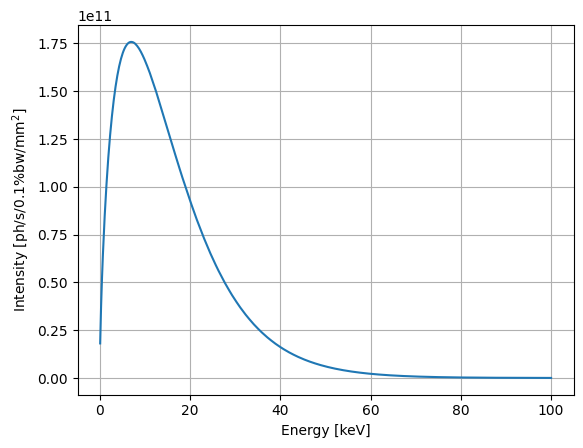

In [3]:
energy = np.linspace(0.1,100,500)*1e3

bm = me.BendingMagnet(B=1.4,L=3)
fields = me.MagnetCnt(magnets=[bm],field_type='bending')

SR = rs.SynchrotronRadiation(energy=energy,d=10,x=0,y=0,fields=fields)
SR.calc_wfr()

arrI, [rangee] = SR.calc_intensity(coords='e',energy=0,X=0,Y=0,polarization='total',intType='SE')

plt.plot(energy*1e-3,arrI)
plt.xlabel('Energy [keV]')
plt.ylabel(r'Intensity [ph/s/0.1%bw/mm$^2$]')
plt.grid()
plt.show()

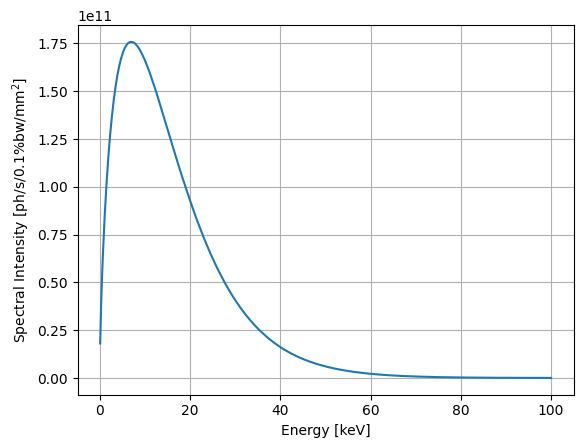

In [4]:
energy = np.linspace(0.1,100,500)*1e3

bm = me.BendingMagnet(B=1.4,L=3)
fields = me.MagnetCnt(magnets=[bm],field_type='bending')

SR = rs.SynchrotronRadiation(energy=energy,d=10,x=0,y=0,fields=fields)
SR.calc_wfr()

rplt.plot_spectrum(SR,X=0,Y=0)

## Undulator

flux density

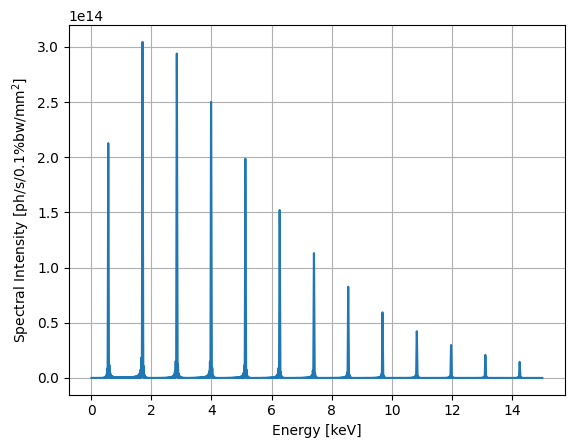

In [5]:
und = me.Undulator(period_length=50e-3,nr_periods=20,Kv=2,Kh=0)
fields = me.MagnetCnt(magnets=[und],field_type='undulator')

energy = np.linspace(0.01,15,7000)*1e3
# adjust the array for the energy points pass exactly on the harmonics into the range:
energy = und.adjust_energy(energy=energy,E=3e9,theta=0)

SR = rs.SynchrotronRadiation(energy=energy,d=10,x=0,y=0,fields=fields)
SR.calc_wfr()

rplt.plot_spectrum(SR,X=0,Y=0)

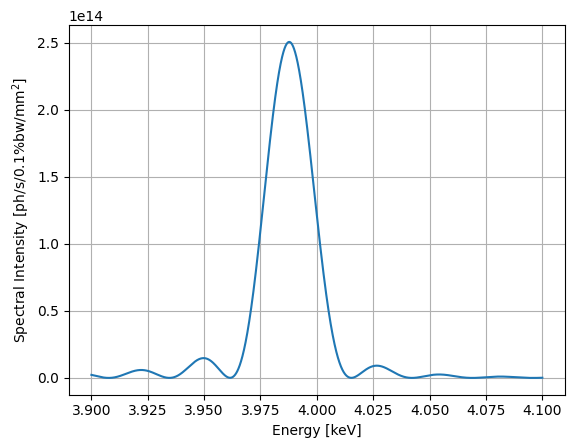

In [2]:
und = me.Undulator(period_length=50e-3,nr_periods=20,Kv=2,Kh=0)
fields = me.MagnetCnt(magnets=[und],field_type='undulator')

energy = np.linspace(4-0.1,4+0.1,7000)*1e3
# adjust the array for the energy points pass exactly on the harmonics into the range:
energy = und.adjust_energy(energy=energy,E=3e9,theta=0)

SR = rs.SynchrotronRadiation(energy=energy,d=10,x=0,y=0,fields=fields)
SR.calc_wfr()

rplt.plot_spectrum(SR,X=0,Y=0)

flux

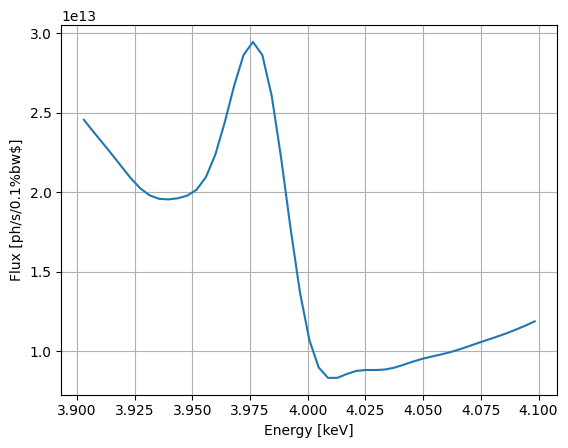

In [23]:
und = me.Undulator(period_length=50e-3,nr_periods=20,Kv=2,Kh=0)
fields = me.MagnetCnt(magnets=[und],field_type='undulator')

w = np.linspace(-5e-4,5e-4,200)
energy = np.linspace(4-0.1,4+0.1,50)*1e3
# adjust the array for the energy points pass exactly on the harmonics into the range:
energy = und.adjust_energy(energy=energy,E=3e9,theta=0)

SR = rs.SynchrotronRadiation(energy=energy,d=5,x=w,y=w,fields=fields)
SR.calc_wfr()

arrF, [rangee] = SR.calc_flux(polarization='total',intType='SE')

plt.plot(energy*1e-3,arrF)
plt.xlabel('Energy [keV]')
plt.ylabel(r'Flux [ph/s/0.1%bw]')
plt.grid()
plt.show()

# Spatial distributions

## Bending

flux densities: horizontal and transverse plane profiles

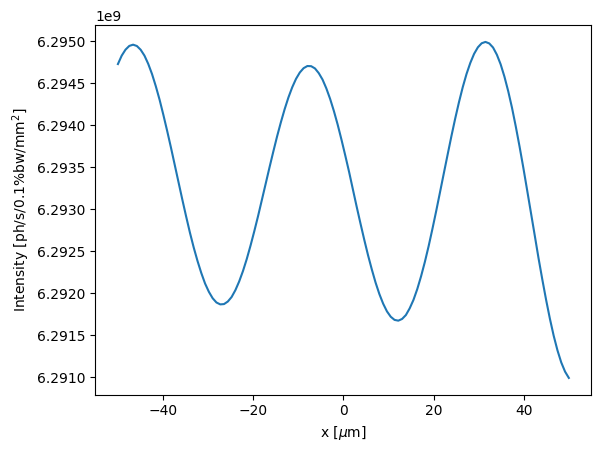

In [6]:
Eph = 20e3
w = np.linspace(-50,50,120)*1e-6

bm = me.BendingMagnet(B=0.5642,L=3)
fields = me.MagnetCnt(magnets=[bm],field_type='bending')

SR = rs.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()

arrI, [rangex] = SR.calc_intensity(coords='x',energy=0,X=0,Y=0,polarization='total',intType='SE')
x = np.linspace(*rangex)*1e6

plt.plot(x,arrI)
plt.xlabel(r'x [$\mu$m]')
plt.ylabel(r'Intensity [ph/s/0.1%bw/mm$^2$]')
plt.show()

#OBS: Notice the scale of variation of the intensity. The oscillation is result of accumulation of numerical errors, the intensity is almost constant or constant varying

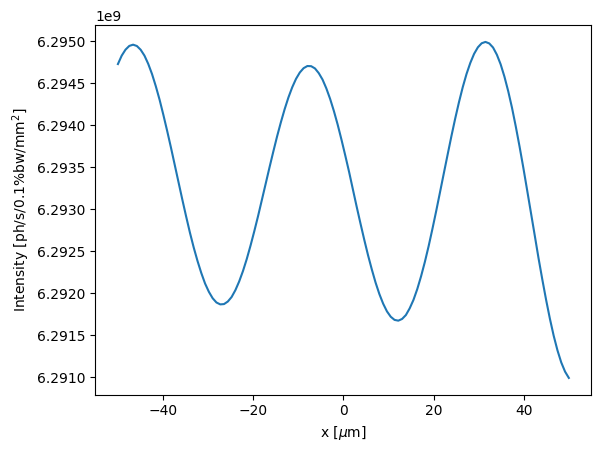

In [7]:
Eph = 20e3
w = np.linspace(-50,50,120)*1e-6

bm = me.BendingMagnet(B=0.5642,L=3)
fields = me.MagnetCnt(magnets=[bm],field_type='bending')

SR = rs.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()

rplt.plot_wfr_inten(SR,coords='x',energy=Eph,X=0,Y=0,intType='SE',
                    xlabel=r'x [$\mu$m]',ylabel=r'Intensity [ph/s/0.1%bw/mm$^2$]')

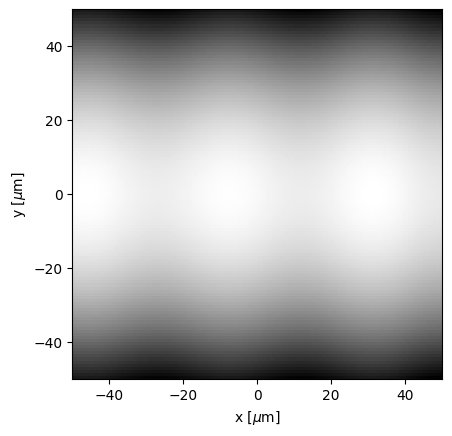

In [8]:
Eph = 20e3
w = np.linspace(-50,50,120)*1e-6

bm = me.BendingMagnet(B=0.5642,L=3)
fields = me.MagnetCnt(magnets=[bm],field_type='bending')

SR = rs.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()

rplt.plot_wfr_inten(SR,coords='xy',energy=Eph,X=0,Y=0,intType='SE',
                    xlabel=r'x [$\mu$m]',ylabel=r'y [$\mu$m]')

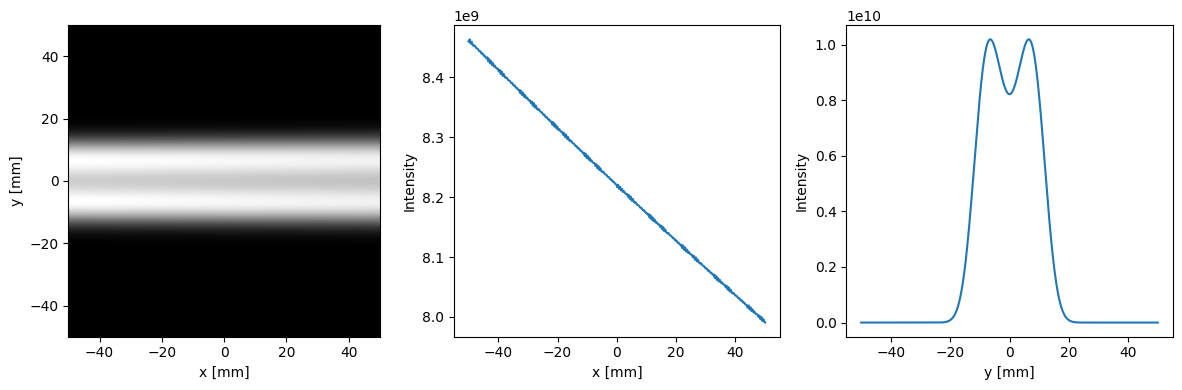

In [9]:
bm = me.BendingMagnet(B=1.4,L=4)
fields = me.MagnetCnt(magnets=[bm],field_type='bending')

Eph = uti.wavelength_to_energy(325e-9)
w = np.linspace(-50,50,100)*1e-3

SR = rs.SynchrotronRadiation(energy=Eph,d=5,x=w,y=w,fields=fields)
SR.precisions['sampling'] = 0.1
SR.calc_wfr()


plt.figure(figsize=(12,4))
ax1 = plt.subplot(1,3,1)
ax2 = plt.subplot(1,3,2)
ax3 = plt.subplot(1,3,3)

rplt.plot_wfr_inten(SR,coords='xy',energy=Eph,X=0,Y=0, ax=ax1, aspect='equal',
                    xlabel='x [mm]',ylabel='y [mm]',unit='mm')
rplt.plot_wfr_inten(SR,coords='x',energy=Eph,X=0,Y=0, ax=ax2,
                    xlabel='x [mm]',ylabel='Intensity',unit='mm')
rplt.plot_wfr_inten(SR,coords='y',energy=Eph,X=0,Y=0, ax=ax3,
                    xlabel='y [mm]',ylabel='Intensity',unit='mm')

plt.tight_layout()
plt.show()

polarizations

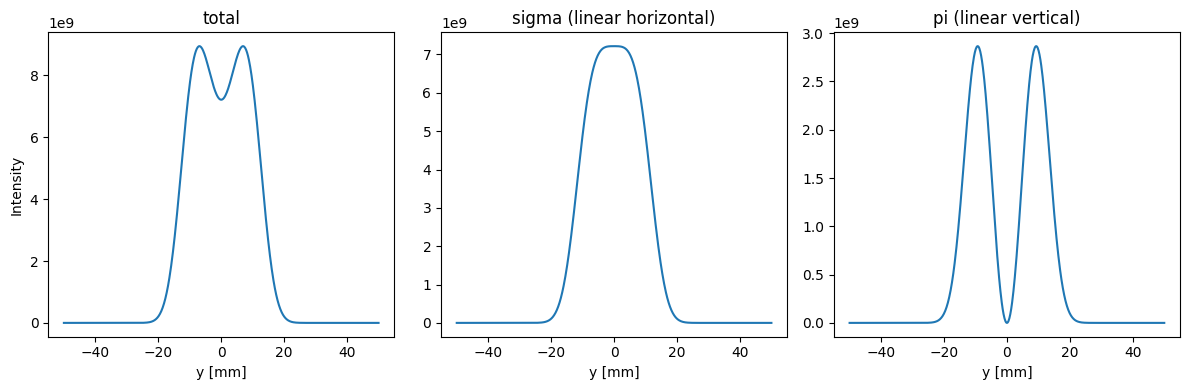

In [10]:
bm = me.BendingMagnet(B=1.4,L=4)
fields = me.MagnetCnt(magnets=[bm],field_type='bending')

Eph = uti.wavelength_to_energy(325e-9)
w = np.linspace(-50,50,100)*1e-3

SR = rs.SynchrotronRadiation(energy=Eph,d=5.336,x=w,y=w,fields=fields)
SR.precisions['sampling'] = 0.1
SR.calc_wfr()


plt.figure(figsize=(12,4))
ax1 = plt.subplot(1,3,1)
ax2 = plt.subplot(1,3,2)
ax3 = plt.subplot(1,3,3)

rplt.plot_wfr_inten(SR,coords='y',energy=Eph,X=0,Y=0,polarization='total',ax=ax1,
                    title='total',xlabel='y [mm]',ylabel='Intensity',unit='mm')
rplt.plot_wfr_inten(SR,coords='y',energy=Eph,X=0,Y=0,polarization='linH',ax=ax2,
                    title='sigma (linear horizontal)',xlabel='y [mm]',unit='mm')
rplt.plot_wfr_inten(SR,coords='y',energy=Eph,X=0,Y=0,polarization='linV',ax=ax3,
                    title='pi (linear vertical)',xlabel='y [mm]',unit='mm')

plt.tight_layout()
plt.show()

phase

In [15]:
Eph = 20e3
w = np.linspace(-50,50,120)*1e-6

bm = me.BendingMagnet(B=0.5642,L=3)
fields = me.MagnetCnt(magnets=[bm],field_type='bending')

SR = rs.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()

arrP, [rangex, rangey] = SR.calc_electric_field(part='phase',coords='xy',energy=0,X=0,Y=0)
xi, xf, nx, yi, yf, ny = *rangex, *rangey
arrP = np.array(arrP).reshape(ny,nx)

limits = SR.window_limits() * 1e6

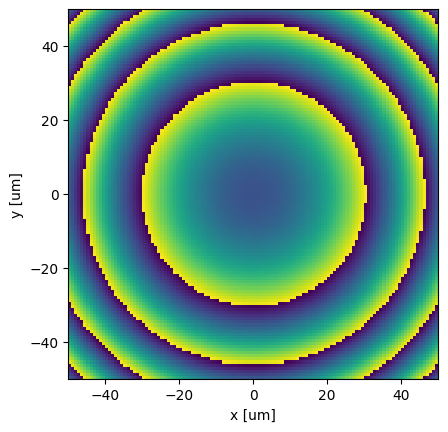

In [16]:
plt.imshow(arrP,extent=limits,aspect='equal')
plt.xlabel('x [um]')
plt.ylabel('y [um]')
plt.show()

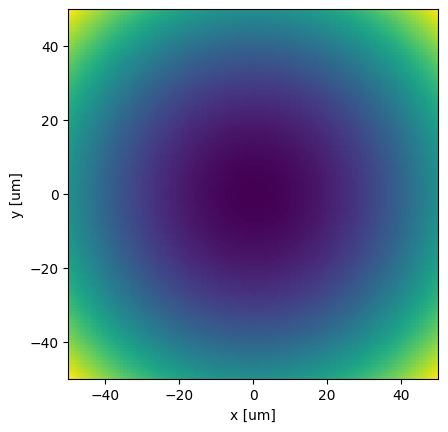

In [17]:
arrP_unw = rs.SynchrotronRadiation.unwrap_phase(arrP)

plt.imshow(arrP_unw,extent=limits,aspect='equal')
plt.xlabel('x [um]')
plt.ylabel('y [um]')
plt.show()

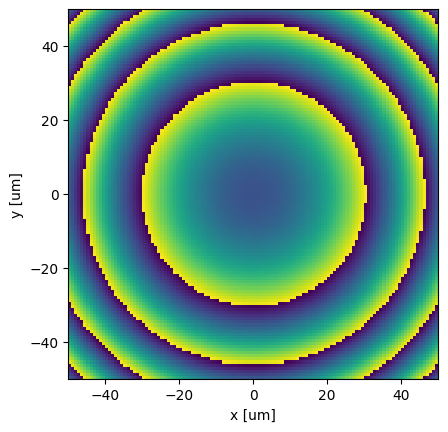

In [18]:
arrP_w = rs.SynchrotronRadiation.wrap_phase(arrP_unw)

plt.imshow(arrP_w,extent=limits,aspect='equal')
plt.xlabel('x [um]')
plt.ylabel('y [um]')
plt.show()

## Undulator

flux density

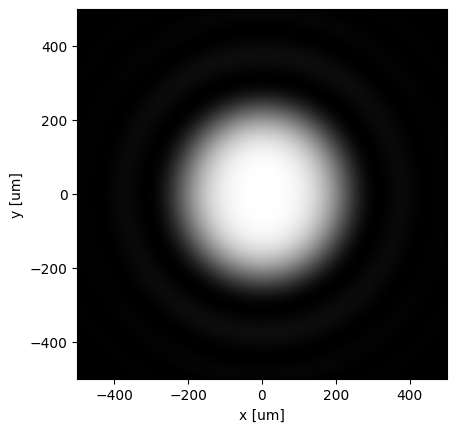

In [19]:
und = me.Undulator(period_length=50e-3,nr_periods=20,Kv=2,Kh=0)
fields = me.MagnetCnt(magnets=[und],field_type='undulator')

w = np.linspace(-5e-4,5e-4,200)
Eph = und.harmonic_energy(harmn=1,E=3e9,theta=0)

SR = rs.SynchrotronRadiation(energy=Eph,d=5,x=w,y=w,fields=fields)
SR.calc_wfr()

arrI, [rangex,rangey] = SR.calc_intensity(coords='xy',energy=SR.wfr.mesh.eStart,X=0,Y=0,polarization='total',intType='SE')
xi, xf, nx, yi, yf, ny = *rangex, *rangey
arrI = np.array(arrI).reshape(ny,nx)

limits = SR.window_limits() * 1e6
plt.imshow(arrI,cmap='gray',extent=limits)
plt.ylabel('y [um]')
plt.xlabel('x [um]')
plt.show()

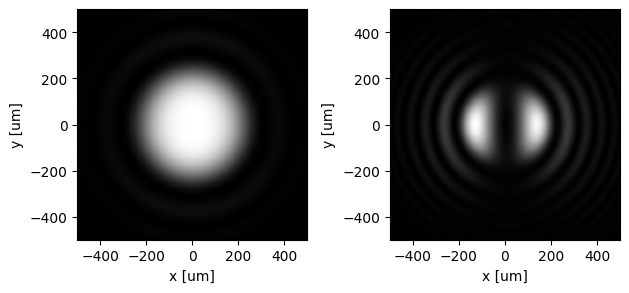

In [20]:
und = me.Undulator(period_length=50e-3,nr_periods=20,Kv=2,Kh=0)
fields = me.MagnetCnt(magnets=[und],field_type='undulator')

w = np.linspace(-5e-4,5e-4,200)
Eph1 = und.harmonic_energy(harmn=1,E=3e9,theta=0)
Eph2 = und.harmonic_energy(harmn=2,E=3e9,theta=0)

ax1 = plt.subplot(121)
ax2 = plt.subplot(122)

for ax, Eph in zip([ax1,ax2],[Eph1,Eph2]):

    SR = rs.SynchrotronRadiation(energy=Eph,d=5,x=w,y=w,fields=fields)
    SR.calc_wfr()

    arrI, [rangex,rangey] = SR.calc_intensity(coords='xy',energy=SR.wfr.mesh.eStart,X=0,Y=0,polarization='total',intType='SE')
    xi, xf, nx, yi, yf, ny = *rangex, *rangey
    arrI = np.array(arrI).reshape(ny,nx)

    limits = SR.window_limits() * 1e6
    ax.imshow(arrI,cmap='gray',extent=limits)
    ax.set_ylabel('y [um]')
    ax.set_xlabel('x [um]')

plt.tight_layout()
plt.show()

# Optical elements

drift

In [38]:
drift = oe.Drift(dist=10)

propagation parameters

In [21]:
drift = oe.Drift(dist=10)
drift.prop_params['propagator'] = 'Quadratic'
drift.prop_params['ra'] = 4 # horizontal and vertical range factors
drift.prop_params['re'] = 2 # horizontal and vertical resolution factors
drift.prop_params['re_v'] = 3 # vertical resolution factor
drift.prop_params['auto_rs_before'] = True # resize wavefront before propagation
# ...

# check the current parameters of some optical element
print(drift.prop_params)

auto_rs_before : True
auto_rs_after  : False
auto_rs_prec   : 1.0
propagator     : 1
rs             : False
ra_h           : 4
re_h           : 2
ra_v           : 4
re_v           : 3
p1             : 0
p2             : 0
p3             : 0



aperture

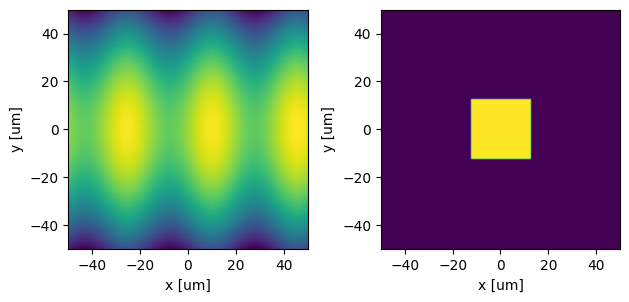

In [23]:
Eph = 22e3

w = np.linspace(-50,50,120)*1e-6

bm = me.BendingMagnet(B=0.5642,L=3)
fields = me.MagnetCnt(magnets=[bm],field_type='bending')

SR = rs.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()

ax1 = plt.subplot(121)
rplt.plot_wfr_inten(SR,coords='xy',energy=Eph,X=0,Y=0,
                    ax=ax1, cmap='viridis', xlabel='x [um]', ylabel='y [um]')


apert = 25e-6

aper = oe.Slit(apert,apert)

bl = rs.Beamline(line=[aper])
SR.propagate_wfr(beamline=bl)

ax2 = plt.subplot(122)
rplt.plot_wfr_inten(SR,coords='xy',energy=Eph,X=0,Y=0,
                    ax=ax2, cmap='viridis', xlabel='x [um]', ylabel='y [um]')

plt.tight_layout()
plt.show()

fresnel zone plate

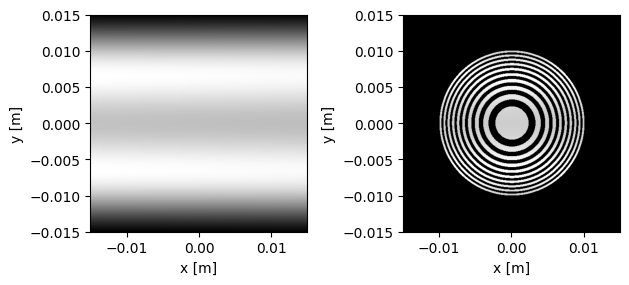

In [24]:
bm = me.BendingMagnet(B=1.4,L=3)
fields = me.MagnetCnt(magnets=[bm],field_type='bending')

w = np.linspace(-15,15,500)*1e-3

SR = rs.SynchrotronRadiation(energy=3.8,d=5,x=w,y=w,fields=fields)
SR.calc_wfr()

ax1 = plt.subplot(121)
rplt.plot_wfr_inten(SR,coords='xy',energy=Eph,X=0,Y=0,
                    ax=ax1, unit='m', xlabel='x [m]', ylabel='y [m]')


zp = oe.FresnelZonePlate(nr_zones=19,radius_n=0.01)
bl = rs.Beamline(line=[zp])
SR.propagate_wfr(beamline=bl)


ax2 = plt.subplot(122)
rplt.plot_wfr_inten(SR,coords='xy',energy=Eph,X=0,Y=0,
                    ax=ax2, unit='m', xlabel='x [m]', ylabel='y [m]')

plt.tight_layout()
plt.show()

# Beamlines

simple propagation

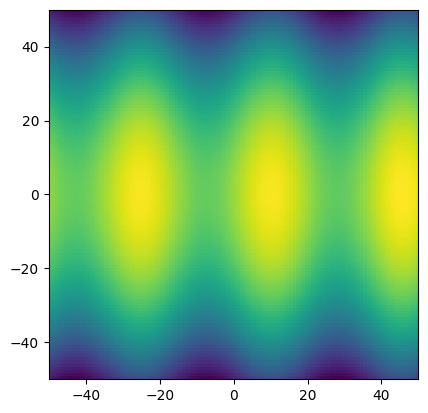

In [25]:
Eph = 22e3
apert = 25e-6
w = np.linspace(-50,50,120)*1e-6

bm = me.BendingMagnet(B=0.5642,L=3)
fields = me.MagnetCnt(magnets=[bm],field_type='bending')

SR = rs.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()


arrI, [rangex,rangey] = SR.calc_intensity(coords='xy',energy=Eph,X=0,Y=0,polarization='total',intType='SE')
xi, xf, nx, yi, yf, ny = *rangex, *rangey
arrI = np.array(arrI).reshape(ny,nx)

limits = SR.window_limits() * 1e6
plt.imshow(arrI,extent=limits)
plt.show()

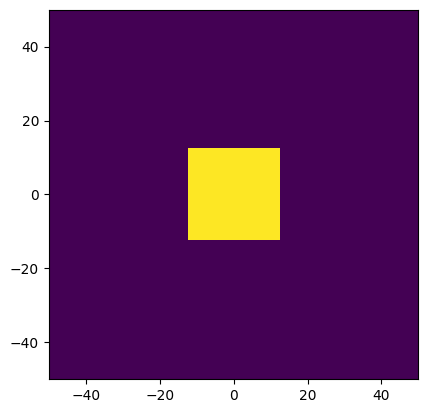

In [27]:
Eph = 22e3
apert = 25e-6
w = np.linspace(-50,50,120)*1e-6

bm = me.BendingMagnet(B=0.5642,L=3)
fields = me.MagnetCnt(magnets=[bm],field_type='bending')

SR = rs.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()

aper = oe.Slit(apert,apert)

bl = rs.Beamline(line=[aper])
SR.propagate_wfr(beamline=bl)


arrI, [rangex,rangey] = SR.calc_intensity(coords='xy',energy=Eph,X=0,Y=0,polarization='total',intType='SE')
xi, xf, nx, yi, yf, ny = *rangex, *rangey
arrI = np.array(arrI).reshape(ny,nx)

limits = SR.window_limits() * 1e6
plt.imshow(arrI,extent=limits)
plt.show()

## Pinhole

construction of the beamline

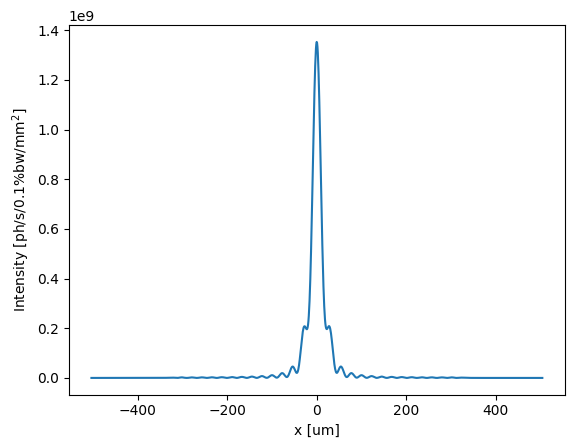

In [28]:
Eph = 22e3
apert = 25e-6
w = np.linspace(-50,50,120)*1e-6

bm = me.BendingMagnet(B=0.5642,L=3)
fields = me.MagnetCnt(magnets=[bm],field_type='bending')

SR = rs.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()

filtro = oe.AbsorptionFilter(x=w,y=w,energy=Eph,thickness=1e-3,material='Al')
aper = oe.Slit(apert,apert)
aper.prop_params['ra'] = 10.0
screen = oe.Drift(dist=10)
bl = rs.Beamline(line=[filtro,aper,screen])
SR.propagate_wfr(beamline=bl)

arrIx, [rangex] = SR.calc_intensity(coords='x',energy=Eph,X=0,Y=0,polarization='total',intType='SE')
x = np.linspace(*rangex)*1e6

plt.plot(x,arrIx)
plt.xlabel('x [um]')
plt.ylabel(r'Intensity [ph/s/0.1%bw/mm$^2$]')
plt.show()

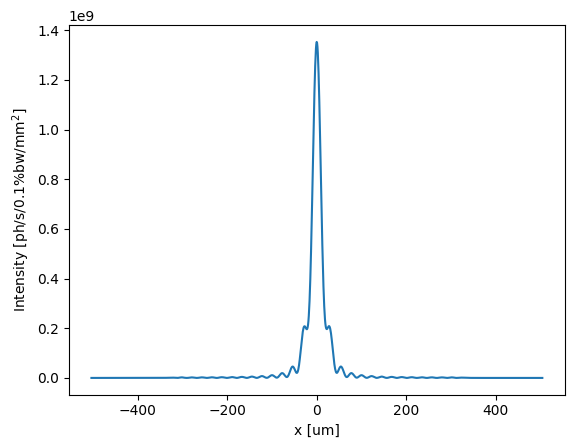

In [2]:
w = np.linspace(-50,50,120)*1e-6
SR = bln.PinholeLine(energy=22e3,d=10,D=10,x=w,y=w,apertx=25e-6,aperty=25e-6)

rplt.plot_wfr_inten(SR,coords='x',energy=22e3,X=0,Y=0,
                    xlabel='x [um]',ylabel=r'Intensity [ph/s/0.1%bw/mm$^2$]')

fluence

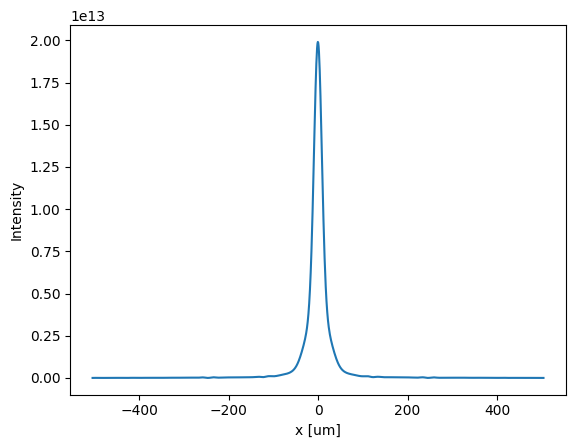

In [3]:
energy = np.linspace(10,50,21)*1e3
w = np.linspace(-50,50,120)*1e-6
SR = bln.PinholeLine(energy=energy,d=10,D=10,x=w,y=w,apertx=25e-6,aperty=25e-6)

rplt.plot_wfr_inten(SR,coords='x',energy=0,X=0,Y=0,intType='SE Fluence',xlabel='x [um]',ylabel='Intensity')

electric field

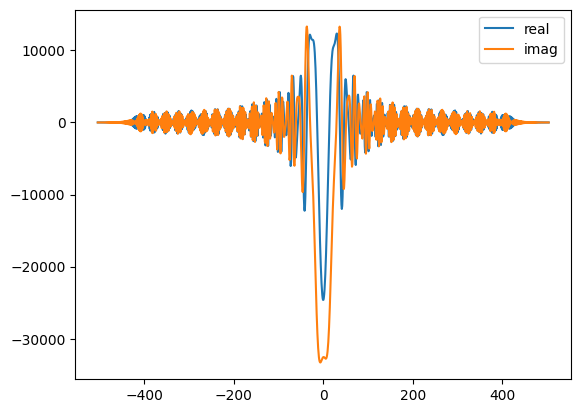

In [4]:
w = np.linspace(-50,50,120)*1e-6
SR = bln.PinholeLine(energy=17.5e3,d=10,D=10,x=w,y=w,apertx=25e-6,aperty=25e-6)

arrReE, [rangex] = SR.calc_electric_field(part='re',coords='x',energy=0,X=0,Y=0,polarization='total')
arrImE, [rangex] = SR.calc_electric_field(part='im',coords='x',energy=0,X=0,Y=0,polarization='total')
x = np.linspace(*rangex)*1e6

plt.plot(x,arrReE,label='real')
plt.plot(x,arrImE,label='imag')
plt.legend()
plt.show()

gaussian fitting

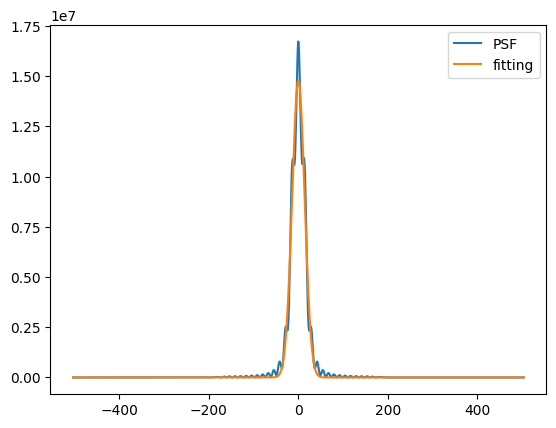

In [2]:
Eph = 40e3
w = np.linspace(-50,50,120)*1e-6
SR = bln.PinholeLine(energy=Eph,d=10,D=10,x=w,y=w,apertx=25e-6,aperty=25e-6)

arrIx, [rangex] = SR.calc_intensity(coords='x',energy=Eph,X=0,Y=0,polarization='total',intType='SE')
x = np.linspace(*rangex)*1e6

params = uti.fitgaussian(x,arrIx)

plt.plot(x,arrIx,label='PSF')
plt.plot(x,uti.gaussian(x,*params),label='fitting')
plt.legend()
plt.show()

FWHM of peak-type intensities

FWHM:
- x: 26.07
- y: 26.08


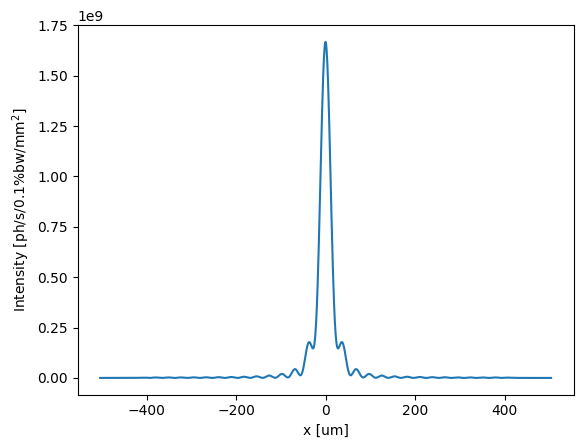

In [4]:
w = np.linspace(-50,50,120)*1e-6
SR = bln.PinholeLine(energy=17.5e3,d=10,D=10,x=w,y=w,apertx=25e-6,aperty=25e-6)

print("FWHM:",
      f"- x: {uti.fwhm_SR(SR,coords='x',energy=Eph,X=0,Y=0):.2f}",
      f"- y: {uti.fwhm_SR(SR,coords='y',energy=Eph,X=0,Y=0):.2f}",
      sep='\n')
rplt.plot_wfr_inten(SR,coords='x',energy=Eph,X=0,Y=0,
                    xlabel='x [um]',ylabel=r'Intensity [ph/s/0.1%bw/mm$^2$]')

caustic

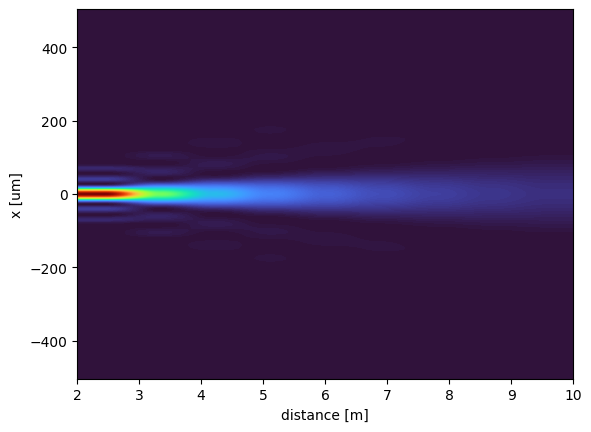

In [5]:
Eph = 17.5e3
w = np.linspace(-50,50,120)*1e-6
apert = 5e-6

bm = me.BendingMagnet(B=0.5642,L=2)
fields = me.MagnetCnt(magnets=[bm],field_type='bending')

SR = rs.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()

filtro = oe.AbsorptionFilter(x=w,y=w,energy=Eph,thickness=1e-3,material='Al')
aper = oe.Slit(apert,apert)
aper.prop_params['ra'] = 10.0
# screen = Slit(dist=d)
# bl = Beamline(line=[filtro,aper,screen])
bl = rs.Beamline(line=[filtro,aper])
SR.propagate_wfr(beamline=bl)


distances = np.linspace(2,10,9)

arrsI, ranges = bln.caustic(SR,dists=distances,coord='x',energy=Eph,X=0,Y=0)

limits = [distances[0],distances[-1],ranges[0][0]*1e6,ranges[0][1]*1e6]
plt.imshow(arrsI,extent=limits,aspect='auto',cmap='turbo')
plt.ylabel('x [um]')
plt.xlabel('distance [m]')
plt.show()

## Toroidal Mirror

FWHM:
- x: 0.43
- y: 0.71


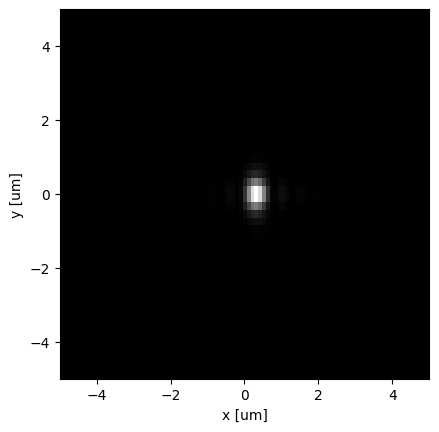

In [3]:
w = np.linspace(-3,3,200)*1e-3
SR = bln.ToroidalMirrorLine(energy=11e3,d=17,D=17,x=w,y=w,apertx=4e-3,aperty=4e-3,
                            ang=18.78e-3,tang_len=0.22,sag_len=0.008,R_tang=905.271,
                            R_sag=0.3192)

print("FWHM:",
      f"- x: {uti.fwhm_SR(SR,coords='x',energy=11e3,X=0,Y=0):.2f}",
      f"- y: {uti.fwhm_SR(SR,coords='y',energy=11e3,X=0,Y=0):.2f}",
      sep='\n')
rplt.plot_wfr_inten(SR,coords='xy',energy=11e3,X=0,Y=0,aspect='equal',
                    xlim=(-5,5),ylim=(-5,5),xlabel='x [um]',ylabel='y [um]')

## CARCARA

FWHM:
- x: 0.44
- y: 0.86


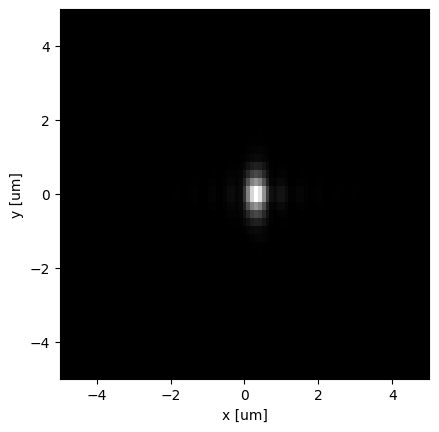

In [2]:
SR = bln.Carcara(apertx=5e-3,aperty=5e-3)

print("FWHM:",
      f"- x: {uti.fwhm_SR(SR,coord='x',energy=11e3,X=0,Y=0):.2f}",
      f"- y: {uti.fwhm_SR(SR,coord='y',energy=11e3,X=0,Y=0):.2f}",
      sep='\n')
rplt.plot_wfr_inten(SR,coords='xy',energy=11e3,X=0,Y=0,aspect='equal',
               xlim=(-5,5),ylim=(-5,5),xlabel='x [um]',ylabel='y [um]')

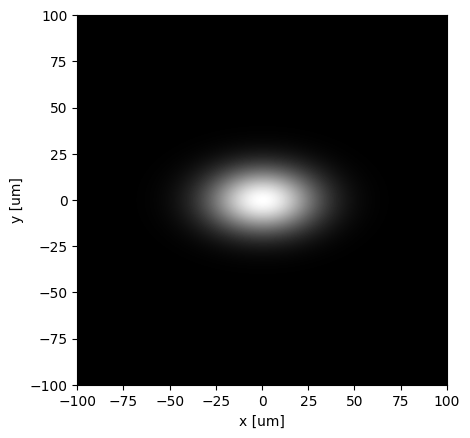

In [3]:
SR = bln.Carcara(apertx=5e-3,aperty=5e-3)

rplt.plot_wfr_inten(SR,coords='xy',energy=11e3,X=0,Y=0,aspect='equal',intType='ME',
                    xlabel='x [um]',ylabel='y [um]',xlim=(-100,100),ylim=(-100,100))

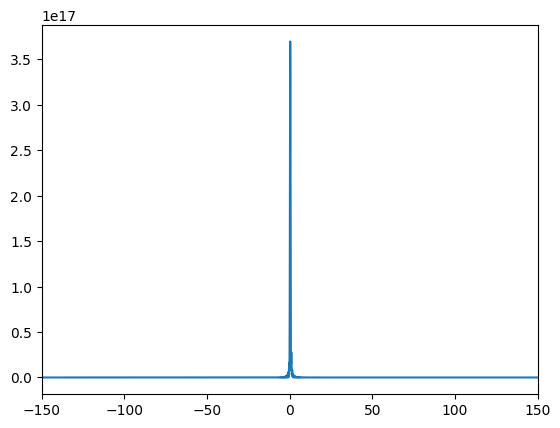

In [4]:
SR = bln.Carcara(apertx=5e-3,aperty=5e-3,mirror_error='')

rplt.plot_wfr_inten(SR,coords='x',energy=11e3,X=0,Y=0,xlim=(-150,150))

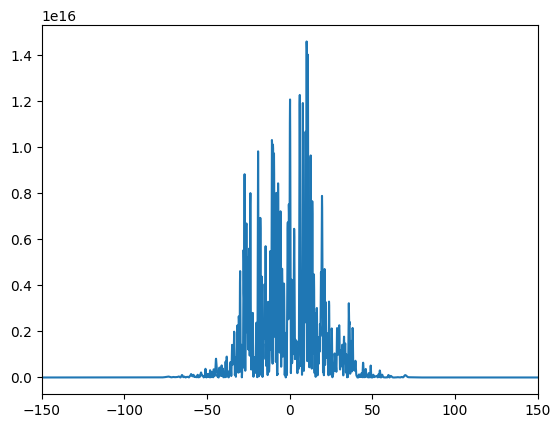

In [5]:
SR = bln.Carcara(apertx=5e-3,aperty=5e-3,mirror_error='meas')

rplt.plot_wfr_inten(SR,coords='x',energy=11e3,X=0,Y=0,xlim=(-150,150))

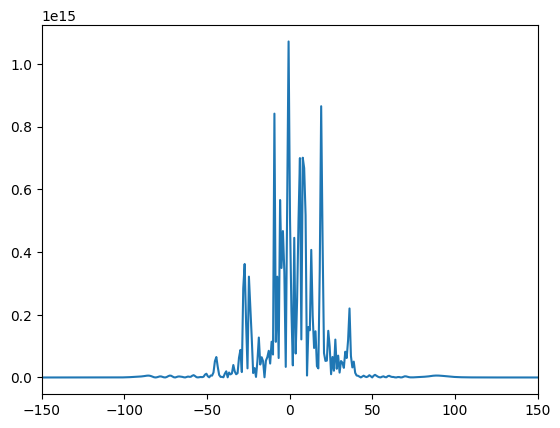

In [6]:
SR = bln.Carcara(apertx=1e-3,aperty=1e-3,mirror_error='meas')

rplt.plot_wfr_inten(SR,coords='x',energy=11e3,X=0,Y=0,xlim=(-150,150))